# Bootstrap Validation — Naked Fixed-Param Models + Threshold Tuning (B=100)

Extension of nb29 adding OOF threshold tuning per iteration.
Goal: compare recall and F1 stability between naked models and Light RF (nb33).

**Threshold tuning:** OOF F1 maximized subject to precision ≥ 0.60 floor (matching Yundi's pipeline).

**Per iteration:** fit fixed-param model → OOF threshold tuning (maximize F1) → evaluate on fixed test set  
**Tracked:** test AUC · OOF threshold · precision · recall · F1 · brier

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, brier_score_loss,
    precision_score, recall_score, f1_score
)
from sklearn.model_selection import train_test_split, StratifiedKFold

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [2]:
B            = 100
RANDOM_STATE = 42
N_SPLITS     = 5
BOOT_MODELS  = ['CatBoost', 'XGBoost', 'Random Forest']

FIXED_PARAMS = {
    'Random Forest': {
        'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 5,
        'max_features': 'sqrt', 'class_weight': 'balanced',
        'random_state': RANDOM_STATE, 'n_jobs': -1,
    },
    'XGBoost': {
        'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3,
        'subsample': 0.8, 'colsample_bytree': 0.8,
        'random_state': RANDOM_STATE, 'eval_metric': 'logloss', 'verbosity': 0,
    },
    'CatBoost': {
        'iterations': 200, 'learning_rate': 0.05, 'depth': 4,
        'random_seed': RANDOM_STATE, 'verbose': 0,
    },
}

PRECISION_FLOOR = 0.60

# Light RF (nb33) bootstrap reference
NB33_RF = {'auc': 0.7563, 'recall': 0.6861, 'f1': 0.6511, 'precision': 0.6276}

df = pd.read_csv('../../df_artists_final.csv', index_col=0).reset_index()
X  = df.drop(columns=['top_20_hitmaker'])
y  = df['top_20_hitmaker']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Class balance (train): {y_train.mean():.3f} hitmaker')

Train: (607, 26)  Test: (152, 26)
Class balance (train): 0.432 hitmaker


In [3]:
def build_model(name, seed):
    p = FIXED_PARAMS[name].copy()
    if name == 'Random Forest':
        p['random_state'] = seed
        return RandomForestClassifier(**p)
    elif name == 'XGBoost':
        p['random_state'] = seed
        return XGBClassifier(**p)
    elif name == 'CatBoost':
        p['random_seed'] = seed
        return CatBoostClassifier(**p)


def run_one_model(name, X_tr, y_tr, X_te, y_te, seed):
    imp      = SimpleImputer(strategy='median')
    X_tr_imp = pd.DataFrame(imp.fit_transform(X_tr), columns=X_tr.columns)
    X_te_imp = pd.DataFrame(imp.transform(X_te),     columns=X_te.columns)

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)

    # OOF threshold tuning
    oof_proba = np.zeros(len(y_tr))
    for tr, va in skf.split(X_tr_imp, y_tr):
        m = build_model(name, seed)
        m.fit(X_tr_imp.iloc[tr], y_tr.iloc[tr])
        oof_proba[va] = m.predict_proba(X_tr_imp.iloc[va])[:, 1]

    thresholds = np.arange(0.05, 0.95, 0.01)
    f1s   = np.array([f1_score(y_tr, (oof_proba >= t).astype(int), zero_division=0) for t in thresholds])
    precs = np.array([precision_score(y_tr, (oof_proba >= t).astype(int), zero_division=0) for t in thresholds])
    valid_mask = precs >= PRECISION_FLOOR
    if valid_mask.any():
        best_idx = np.argmax(np.where(valid_mask, f1s, -np.inf))
    else:
        best_idx = np.argmax(precs)
    best_t = round(thresholds[best_idx], 2)

    # Final fit on full training set
    model = build_model(name, seed)
    model.fit(X_tr_imp, y_tr)
    test_proba = model.predict_proba(X_te_imp)[:, 1]
    y_pred     = (test_proba >= best_t).astype(int)

    return {
        'test_auc':  roc_auc_score(y_te, test_proba),
        'brier':     brier_score_loss(y_te, test_proba),
        'threshold': best_t,
        'precision': precision_score(y_te, y_pred, zero_division=0),
        'recall':    recall_score(y_te, y_pred, zero_division=0),
        'f1':        f1_score(y_te, y_pred, zero_division=0),
    }

## Bootstrap Loop

In [4]:
METRICS  = ['test_auc', 'brier', 'threshold', 'precision', 'recall', 'f1']
results  = {name: {m: [] for m in METRICS} for name in BOOT_MODELS}
results['Baseline'] = {'test_auc': []}

rng = np.random.default_rng(RANDOM_STATE)

for b in range(B):
    seed     = RANDOM_STATE + b
    boot_idx = rng.choice(len(X_train), size=len(X_train), replace=True)
    X_tr_b   = X_train.iloc[boot_idx].reset_index(drop=True)
    y_tr_b   = y_train.iloc[boot_idx].reset_index(drop=True)

    print(f'[{b+1:02d}/{B}] ', end='', flush=True)

    for name in BOOT_MODELS:
        print(f'{name}... ', end='', flush=True)
        try:
            res = run_one_model(name, X_tr_b, y_tr_b, X_test, y_test, seed)
            for m in METRICS:
                results[name][m].append(res[m])
            print(f'AUC={res["test_auc"]:.3f} thr={res["threshold"]:.2f} '
                  f'P={res["precision"]:.3f} R={res["recall"]:.3f} F1={res["f1"]:.3f} | ',
                  end='', flush=True)
        except Exception as e:
            print(f'ERROR({e}) | ', end='', flush=True)
            for m in METRICS:
                results[name][m].append(np.nan)

    dummy = DummyClassifier(strategy='stratified', random_state=seed)
    dummy.fit(X_tr_b, y_tr_b)
    results['Baseline']['test_auc'].append(
        roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1])
    )
    print(f'Baseline={results["Baseline"]["test_auc"][-1]:.3f}')

    with open('../../ml_sandbox/bootstrap_naked_threshold_results.pkl', 'wb') as f:
        pickle.dump(results, f)

print('\nDone. Results saved to bootstrap_naked_threshold_results.pkl')

[01/100] CatBoost... AUC=0.747 thr=0.45 P=0.629 R=0.667 F1=0.647 | XGBoost... AUC=0.718 thr=0.39 P=0.583 R=0.636 F1=0.609 | Random Forest... AUC=0.732 thr=0.43 P=0.543 R=0.758 F1=0.633 | Baseline=0.492
[02/100] CatBoost... AUC=0.778 thr=0.43 P=0.701 R=0.712 F1=0.707 | XGBoost... AUC=0.750 thr=0.34 P=0.596 R=0.803 F1=0.684 | Random Forest... AUC=0.756 thr=0.45 P=0.571 R=0.788 F1=0.662 | Baseline=0.506
[03/100] CatBoost... AUC=0.775 thr=0.47 P=0.694 R=0.652 F1=0.672 | XGBoost... AUC=0.776 thr=0.41 P=0.676 R=0.697 F1=0.687 | Random Forest... AUC=0.781 thr=0.49 P=0.628 R=0.742 F1=0.681 | Baseline=0.501
[04/100] CatBoost... AUC=0.760 thr=0.34 P=0.570 R=0.803 F1=0.667 | XGBoost... AUC=0.749 thr=0.41 P=0.643 R=0.682 F1=0.662 | Random Forest... AUC=0.757 thr=0.44 P=0.520 R=0.788 F1=0.627 | Baseline=0.511
[05/100] CatBoost... AUC=0.725 thr=0.44 P=0.584 R=0.682 F1=0.629 | XGBoost... AUC=0.718 thr=0.33 P=0.535 R=0.803 F1=0.642 | Random Forest... AUC=0.742 thr=0.38 P=0.496 R=0.848 F1=0.626 | Basel

## Results

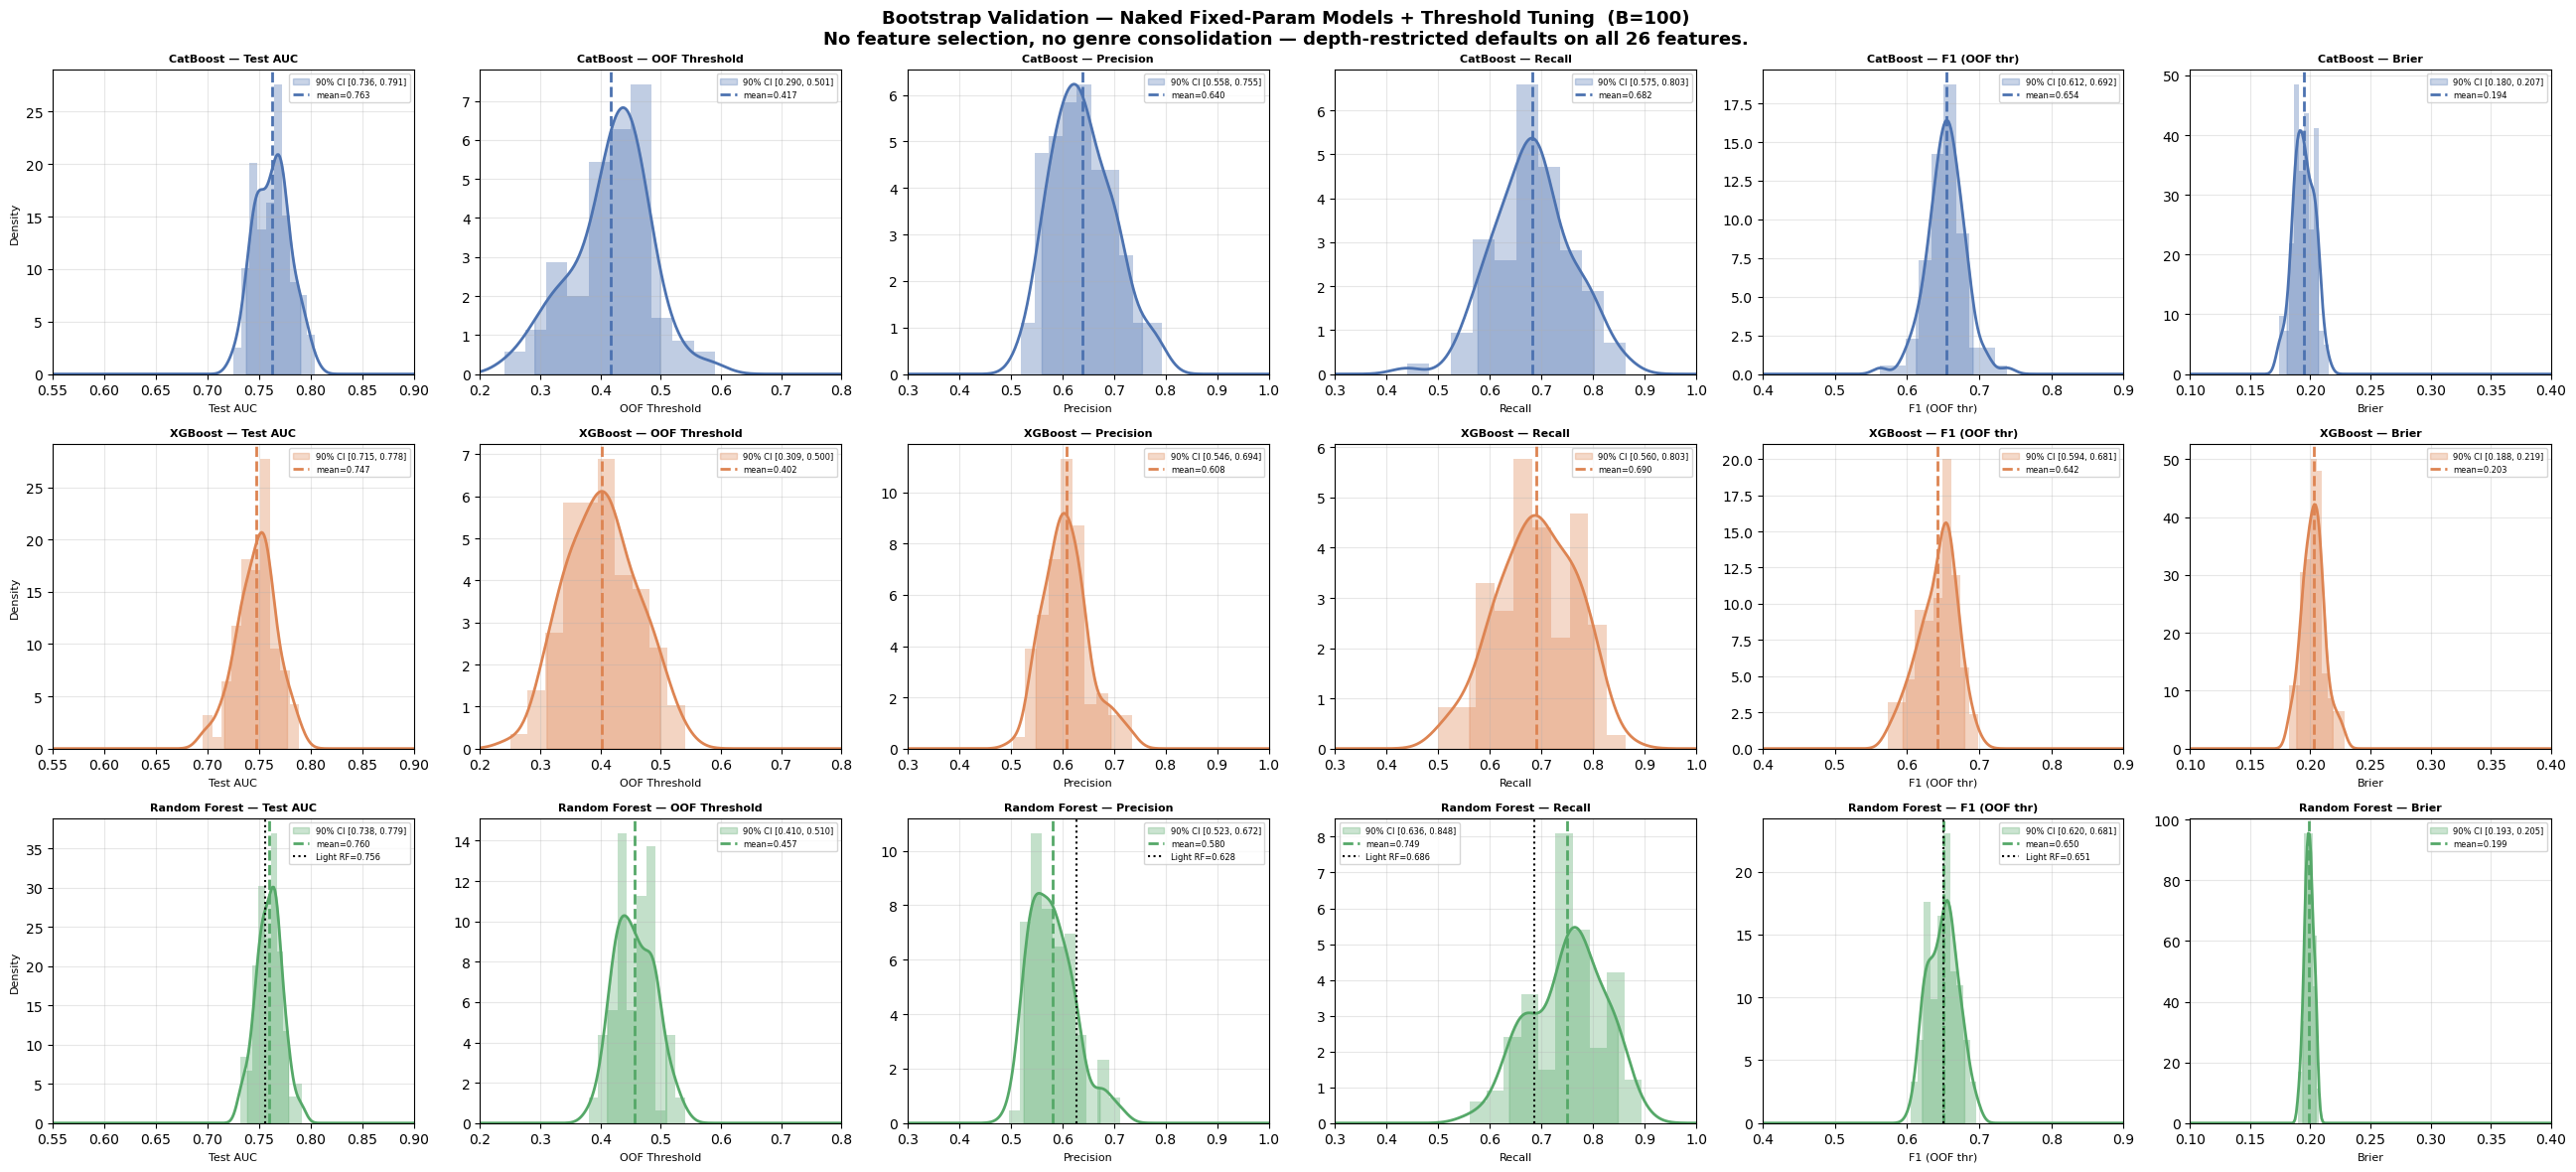

In [5]:
with open('../../ml_sandbox/bootstrap_naked_threshold_results.pkl', 'rb') as f:
    results = pickle.load(f)

palette = {
    'CatBoost':      '#4C72B0',
    'XGBoost':       '#DD8452',
    'Random Forest': '#55A868',
}

plot_metrics = [
    ('test_auc',  'Test AUC',      (0.55, 0.90)),
    ('threshold', 'OOF Threshold', (0.20, 0.80)),
    ('precision', 'Precision',     (0.30, 1.00)),
    ('recall',    'Recall',        (0.30, 1.00)),
    ('f1',        'F1 (OOF thr)',  (0.40, 0.90)),
    ('brier',     'Brier',         (0.10, 0.40)),
]

fig, axes = plt.subplots(3, 6, figsize=(26, 12))
fig.suptitle(
    f'Bootstrap Validation — Naked Fixed-Param Models + Threshold Tuning  (B={B})\n'
    'No feature selection, no genre consolidation — depth-restricted defaults on all 26 features.',
    fontsize=13, fontweight='bold'
)

for row, name in enumerate(BOOT_MODELS):
    color = palette[name]
    for col, (metric, label, xlim) in enumerate(plot_metrics):
        ax   = axes[row, col]
        vals = [v for v in results[name][metric] if not np.isnan(v)]
        if not vals:
            ax.set_title(f'{name}\n{label}\n(no data)'); continue

        mu  = np.mean(vals)
        p5  = np.percentile(vals, 5)
        p95 = np.percentile(vals, 95)
        x_grid = np.linspace(*xlim, 300)

        ax.hist(vals, bins=10, color=color, alpha=0.35, density=True)
        try:
            kde   = gaussian_kde(vals, bw_method='scott')
            y_kde = kde(x_grid)
            ax.plot(x_grid, y_kde, color=color, lw=2.0)
            mask = (x_grid >= p5) & (x_grid <= p95)
            ax.fill_between(x_grid[mask], y_kde[mask], alpha=0.30, color=color,
                            label=f'90% CI [{p5:.3f}, {p95:.3f}]')
        except Exception:
            pass

        ax.axvline(mu, color=color, lw=2.0, linestyle='--', label=f'mean={mu:.3f}')

        # Light RF reference lines for RF row
        if name == 'Random Forest':
            ref = NB33_RF.get(metric.replace('test_auc', 'auc'))
            if ref:
                ax.axvline(ref, color='black', lw=1.5, linestyle=':', label=f'Light RF={ref:.3f}')

        ax.set_xlabel(label, fontsize=8)
        ax.set_ylabel('Density' if col == 0 else '', fontsize=8)
        ax.set_title(f'{name} — {label}', fontweight='bold', fontsize=8)
        ax.set_xlim(xlim)
        ax.legend(fontsize=6)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../ml_sandbox/bootstrap_naked_threshold_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
with open('../../ml_sandbox/bootstrap_naked_threshold_results.pkl', 'rb') as f:
    results = pickle.load(f)

print(f'{"": <20}  {"Test AUC":>10}  {"Recall":>10}  {"F1":>10}  {"Precision":>10}  {"Threshold":>10}')
print('─' * 80)

for name in BOOT_MODELS:
    aucs  = [v for v in results[name]['test_auc'] if not np.isnan(v)]
    recs  = [v for v in results[name]['recall']   if not np.isnan(v)]
    f1s   = [v for v in results[name]['f1']       if not np.isnan(v)]
    precs = [v for v in results[name]['precision'] if not np.isnan(v)]
    thrs  = [v for v in results[name]['threshold'] if not np.isnan(v)]
    print(f'{name:<20}  {np.mean(aucs):>10.4f}  {np.mean(recs):>10.4f}  {np.mean(f1s):>10.4f}  {np.mean(precs):>10.4f}  {np.mean(thrs):>10.4f}')
    print(f'{"std":<20}  {np.std(aucs):>10.4f}  {np.std(recs):>10.4f}  {np.std(f1s):>10.4f}  {np.std(precs):>10.4f}  {np.std(thrs):>10.4f}')
    print()

print('─' * 80)
print(f'{"Light RF (nb33)":<20}  {NB33_RF["auc"]:>10.4f}  {NB33_RF["recall"]:>10.4f}  {NB33_RF["f1"]:>10.4f}  {NB33_RF["precision"]:>10.4f}  {"0.4664":>10}')

                        Test AUC      Recall          F1   Precision   Threshold
────────────────────────────────────────────────────────────────────────────────
CatBoost                  0.7628      0.6817      0.6541      0.6396      0.4172
std                       0.0171      0.0750      0.0258      0.0597      0.0649

XGBoost                   0.7475      0.6900      0.6420      0.6081      0.4019
std                       0.0194      0.0759      0.0266      0.0442      0.0590

Random Forest             0.7599      0.7494      0.6500      0.5803      0.4569
std                       0.0125      0.0710      0.0203      0.0443      0.0334

────────────────────────────────────────────────────────────────────────────────
Light RF (nb33)           0.7563      0.6861      0.6511      0.6276      0.4664
